In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/aymanalzahrani7/graduation-projectd/Graduation Project/Cleaned Data From Google Maps/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os, glob, re, pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,f1_score
from sklearn.utils import resample

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import ReduceLROnPlateau

2026-04-26 10:07:52.909436: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777198073.125293      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777198073.192984      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777198073.716753      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777198073.716794      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777198073.716797      55 computation_placer.cc:177] computation placer alr

In [2]:

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models, callbacks

# لو تعمل داخل Jupyter
from IPython.display import display

In [3]:
import os
import pandas as pd
import numpy as np
import re
from tqdm import tqdm

In [4]:
# الإعدادات الأساسية
TEXT_COL = "Text_TR"
# حدد هنا قائمة المسارات التي تحتوي على مجلدات المناطق
INPUT_PATHS = ['/kaggle/input/datasets/aymanalzahrani7/graduation-projectd/Graduation Project/Cleaned Data From Google Maps/']

# =========================================
# 1. قراءة أي ملف (إكسل أو CSV)
# =========================================
def read_any_file(path):
    ext = os.path.splitext(path)[1].lower()
    try:
        if ext in [".xlsx", ".xls"]:
            df = pd.read_excel(path)
        elif ext == ".csv":
            for enc in ["utf-8", "utf-8-sig", "cp1256"]:
                try:
                    df = pd.read_csv(path, encoding=enc)
                    break
                except:
                    continue
        else:
            return None
        
        # تنظيف رؤوس الأعمدة
        df.columns = [str(c).strip() for c in df.columns]
        return df
    except:
        return None

# =========================================
# 2. توحيد عمود النجوم
# =========================================
def standardize_star_column(df):
    for col in df.columns:
        if col.lower() == "stars":
            df = df.rename(columns={col: "Stars"})
            break
    return df

# =========================================
# 3. جلب جميع الملفات من المجلدات والفرعية
# =========================================
def get_all_files(root):
    files_list = []
    # os.walk تغوص داخل كل مجلدات المناطق
    for r, d, f in os.walk(root):
        for file in f:
            if file.lower().endswith((".csv", ".xlsx", ".xls")):
                files_list.append(os.path.join(r, file))
    return files_list

# =========================================
# 4. الوظيفة الرئيسية لتحميل البيانات فقط
# =========================================
def load_simple_reader(paths):
    all_data = []

    for root in paths:
        print(f"📂 Scanning path: {root}")
        files = get_all_files(root)
        print(f"Total files found: {len(files)}")

        for i, f in enumerate(files, 1):
            try:
                df = read_any_file(f)
                if df is None:
                    continue

                df = standardize_star_column(df)

                # التأكد من وجود العمودين المطلوبين فقط
                if TEXT_COL in df.columns and "Stars" in df.columns:
                    df_subset = df[[TEXT_COL, "Stars"]].copy()
                    all_data.append(df_subset)

                if i % 50 == 0:
                    print(f"Progress: {i}/{len(files)} files read.")

            except Exception as e:
                print(f"❌ Error reading file {f}: {e}")

    # دمج كل شيء في DataFrame واحد
    if all_data:
        df_result = pd.concat(all_data, ignore_index=True)
        # تحويل العمود لنص وتصفية القيم المفقودة تماماً (NaN)
        df_result = df_result.dropna(subset=[TEXT_COL, "Stars"])
        df_result[TEXT_COL] = df_result[TEXT_COL].astype(str)
        
        print(f"\n✅ Done! Total rows loaded: {len(df_result)}")
        return df_result
    else:
        print("\n❌ No data found with the required columns.")
        return pd.DataFrame()

# =========================================
# التشغيل
# =========================================
df1 = load_simple_reader(INPUT_PATHS)
print(df1.head())

📂 Scanning path: /kaggle/input/datasets/aymanalzahrani7/graduation-projectd/Graduation Project/Cleaned Data From Google Maps/
Total files found: 442
Progress: 50/442 files read.
Progress: 100/442 files read.
Progress: 150/442 files read.
Progress: 200/442 files read.
Progress: 250/442 files read.
Progress: 300/442 files read.
Progress: 350/442 files read.
Progress: 400/442 files read.

✅ Done! Total rows loaded: 511258
                                              Text_TR  Stars
1   رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...    3.0
5   المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...    4.0
7                                           ممتاز جدا    5.0
9                                          منتزه مميز    5.0
12                                     منتزه جميل جدا    5.0


In [5]:
# =========================================================
# (2) FILTER ONLY TRULY-EMPTY Text_TR (NaN + "" + "nan" + "[]" ...)
# =========================================================
print(f"\n[STEP 2] Using {TEXT_COL} + strong empty filter")

# ✅ الداتا الجديدة
if TEXT_COL not in df1.columns:
    raise ValueError(f"عمود {TEXT_COL} غير موجود في البيانات.")

before2 = len(df1)

# لا نحول إلى string الآن (مهم)
s = df1[TEXT_COL]

empty_like = {
    "", "nan", "NaN", "none", "None", "NONE",
    "<NA>", "[]", "[ ]", "{}", "null", "NULL"
}

empty_mask = (
    s.isna() |
    s.astype(str).str.strip().isin(empty_like)
)

empty_count = int(empty_mask.sum())

# ✅ الناتج الجديد
df2 = df1.loc[~empty_mask].copy()

# العمود الذي سيستخدم لاحقاً للمودل
df2["TEXT_FOR_MODEL"] = df2[TEXT_COL].astype(str).str.strip()

print("\n[STEP 2 RESULT]")
print("Rows before:", before2)
print("Empty-like rows:", empty_count)
print("Rows after:", len(df2))

print("\nSample empty-like values:")
print(s.loc[empty_mask].head(10).astype(str).tolist())


[STEP 2] Using Text_TR + strong empty filter

[STEP 2 RESULT]
Rows before: 511258
Empty-like rows: 0
Rows after: 511258

Sample empty-like values:
[]


In [6]:
# =========================================================
# (4) SAFE TEXT CLEANING (INDEPENDENT)
#   - لا يعتمد على Stars_num أو y_bin
#   - يحافظ على الأعمدة التعريفية
# =========================================================

import re
import pandas as pd

print("\n[STEP 4] Safe Cleaning (Independent)")

TEXT_COL = "Text_TR"

if TEXT_COL not in df2.columns:
    raise ValueError(f"{TEXT_COL} غير موجود في df2")

# =========================
# Regex definitions
# =========================
AR_DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u0652\u0670]")
AR_TATWEEL_RE    = re.compile(r"\u0640")

# =========================
# Safe Arabic normalization
# =========================
def normalize_arabic_safe(text: str) -> str:
    text = AR_DIACRITICS_RE.sub("", text)   # remove diacritics
    text = AR_TATWEEL_RE.sub("", text)      # remove tatweel (ـ)
    text = re.sub(r"[إأآا]", "ا", text)      # unify alef only
    return text

# =========================
# Main cleaning function
# =========================
def clean_text(s):
    if pd.isna(s):
        return ""
    
    s = str(s).strip().lower()
    if not s:
        return ""

    # remove links / emails / mentions / hashtags
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"\S+@\S+", " ", s)
    s = re.sub(r"@\w+", " ", s)
    s = re.sub(r"#\w+", " ", s)

    # remove emojis
    s = re.sub(r"[\U00010000-\U0010ffff]", " ", s)

    # keep Arabic / English / digits / spaces
    s = re.sub(r"[^0-9a-z\u0600-\u06FF\s]", " ", s)

    # safe normalize
    s = normalize_arabic_safe(s)

    # reduce repeated letters (جمييييل -> جمييل)
    s = re.sub(r"(.)\1{2,}", r"\1\1", s)

    # collapse spaces
    s = re.sub(r"\s+", " ", s).strip()

    # remove if numbers only
    if re.fullmatch(r"\d+", s):
        return ""

    return s


# =========================
# Preserve metadata columns if exist
# =========================
META_COLS = ["Stars"]
meta_existing = [c for c in META_COLS if c in df2.columns]

# =========================
# BEFORE dataframe
# =========================
df_before_clean = df2[[TEXT_COL] + meta_existing].copy()
df_before_clean = df_before_clean.rename(columns={TEXT_COL: "text_before"})

display(df_before_clean.head(10))


# =========================
# Apply cleaning
# =========================
df4 = df2.copy()
df4["text_clean"] = df4[TEXT_COL].apply(clean_text)

# =========================
# Compare dataframe
# =========================
df_compare = df4[[TEXT_COL, "text_clean"] + meta_existing].copy()
df_compare = df_compare.rename(columns={TEXT_COL: "text_before"})

display(df_compare.head(20))


# =========================
# Removed rows (empty after clean)
# =========================
df_removed = df_compare[df_compare["text_clean"].str.len() == 0].copy()

print("Removed rows (empty after clean):", len(df_removed))
display(df_removed.head(20))


# =========================
# Final cleaned dataframe
# =========================
df4 = df_compare[df_compare["text_clean"].str.len() > 0].copy()

print("Final cleaned shape:", df4.shape)
print("Columns:", df4.columns.tolist())

display(df4.head(20))


# =========================
# Safety check examples
# =========================
print("\n[CHECK] safe normalization examples:")
for t in ["سيئ", "سيئة", "سيء", "المكان سيئ جدا", "المكان رائع جدا", "12345", "مطعم 123"]:
    print(f"{t}  ->  {clean_text(t)}")


[STEP 4] Safe Cleaning (Independent)


,text_before,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,5.0
9,منتزه مميز,5.0
12,منتزه جميل جدا,5.0
14,دخول الكرفان 80ريال لذا لم ادخل,2.0
15,ممتازة,5.0
17,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,1.0
20,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,3.0
23,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,5.0


,text_before,text_clean,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,ممتاز جدا,5.0
9,منتزه مميز,منتزه مميز,5.0
12,منتزه جميل جدا,منتزه جميل جدا,5.0
14,دخول الكرفان 80ريال لذا لم ادخل,دخول الكرفان 80ريال لذا لم ادخل,2.0
15,ممتازة,ممتازة,5.0
17,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,1.0
20,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,3.0
23,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,5.0


Removed rows (empty after clean): 2641


,text_before,text_clean,Stars
74771,5,,5.0
82957,١٠٠,,5.0
83371,٦٦,,4.0
101483,٩,,1.0
106298,1961,,1.0
106314,2024,,5.0
106366,2023,,5.0
106383,100,,5.0
106390,1361,,5.0
106446,1361,,5.0


Final cleaned shape: (508617, 3)
Columns: ['text_before', 'text_clean', 'Stars']


,text_before,text_clean,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,ممتاز جدا,5.0
9,منتزه مميز,منتزه مميز,5.0
12,منتزه جميل جدا,منتزه جميل جدا,5.0
14,دخول الكرفان 80ريال لذا لم ادخل,دخول الكرفان 80ريال لذا لم ادخل,2.0
15,ممتازة,ممتازة,5.0
17,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,الحذر ثم الحذر خطر الموت فاليوم الله انجانا من...,1.0
20,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,اقل شي ممكن تسوية مقابل الرسوم انك تتهتم بالنظ...,3.0
23,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,اكثر من رائع ونظيف جدايمتاز بالجلسات بين الاشج...,5.0



[CHECK] safe normalization examples:
سيئ  ->  سيئ
سيئة  ->  سيئة
سيء  ->  سيء
المكان سيئ جدا  ->  المكان سيئ جدا
المكان رائع جدا  ->  المكان رائع جدا
12345  ->  
مطعم 123  ->  مطعم 123


In [7]:
df4

,text_before,text_clean,Stars
1,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,رسوم الدخول عالية، ونتمني اعادة النظر في طريقة...,3.0
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0
7,ممتاز جدا,ممتاز جدا,5.0
9,منتزه مميز,منتزه مميز,5.0
12,منتزه جميل جدا,منتزه جميل جدا,5.0
...,...,...,...
1016493,لطيف جيد,لطيف جيد,2.0
1016494,لجميع انشطة الدفع الرباعي,لجميع انشطة الدفع الرباعي,5.0
1016496,واحدة من الاماكن الرائعة في العالم,واحدة من الاماكن الرائعة في العالم,5.0
1016497,في حفيرة نساح روعة المكان,في حفيرة نساح روعة المكان,5.0


In [8]:
df4 = df4[df4["Stars"] != 3]

In [9]:
def convert_stars(star):
    if star >= 4:
        return 1  # إيجابي
    else:
        return 0  # سلبي

df4["label"] = df4["Stars"].apply(convert_stars)

/tmp/ipykernel_55/726487382.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df4["label"] = df4["Stars"].apply(convert_stars)


In [10]:
df4

,text_before,text_clean,Stars,label
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,4.0,1
7,ممتاز جدا,ممتاز جدا,5.0,1
9,منتزه مميز,منتزه مميز,5.0,1
12,منتزه جميل جدا,منتزه جميل جدا,5.0,1
14,دخول الكرفان 80ريال لذا لم ادخل,دخول الكرفان 80ريال لذا لم ادخل,2.0,0
...,...,...,...,...
1016493,لطيف جيد,لطيف جيد,2.0,0
1016494,لجميع انشطة الدفع الرباعي,لجميع انشطة الدفع الرباعي,5.0,1
1016496,واحدة من الاماكن الرائعة في العالم,واحدة من الاماكن الرائعة في العالم,5.0,1
1016497,في حفيرة نساح روعة المكان,في حفيرة نساح روعة المكان,5.0,1


In [11]:
print(df4["label"].value_counts())

label
1    392994
0     60708
Name: count, dtype: int64


In [12]:
df5 = df4[["text_clean", "label"]].dropna()

In [13]:
df5

,text_clean,label
5,المكان حلوو الدخول بالسيارة ب ٥٠ مو علي الشخص ...,1
7,ممتاز جدا,1
9,منتزه مميز,1
12,منتزه جميل جدا,1
14,دخول الكرفان 80ريال لذا لم ادخل,0
...,...,...
1016493,لطيف جيد,0
1016494,لجميع انشطة الدفع الرباعي,1
1016496,واحدة من الاماكن الرائعة في العالم,1
1016497,في حفيرة نساح روعة المكان,1


# Modeling

In [14]:
from datasets import Dataset

dataset = Dataset.from_pandas(df5)
dataset = dataset.train_test_split(test_size=0.2)

In [15]:
from imblearn.over_sampling import RandomOverSampler

# 2) تحويل train إلى pandas
train_df = dataset["train"].to_pandas()

# 3) فصل X و y (فقط على train)
X = train_df[["text_clean"]]
y = train_df["label"]

# 4) تطبيق oversampling
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# 5) إعادة الدمج
train_balanced = pd.concat([X_resampled, y_resampled], axis=1)

# 6) خلط البيانات
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# 7) إرجاعه إلى Dataset
dataset["train"] = Dataset.from_pandas(train_balanced)

In [16]:
print(dataset["train"].to_pandas()["label"].value_counts())
print(dataset["test"].to_pandas()["label"].value_counts())

label
1    314294
0    314294
Name: count, dtype: int64
label
1    78700
0    12041
Name: count, dtype: int64


In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    ignore_mismatched_sizes=True
)

# تعريف اللابلز (مهم)
model.config.id2label = {0: "Negative", 1: "Positive"}
model.config.label2id = {"Negative": 0, "Positive": 1}

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-da-sentiment
Key                          | Status     |                                                                                     
-----------------------------+------------+-------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.weight            | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [18]:
def tokenize(batch):
    return tokenizer(batch["text_clean"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/628588 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Map:   0%|          | 0/90741 [00:00<?, ? examples/s]

In [19]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./camel_binary",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=4,
    logging_dir="./logs",
    save_steps=0   # مهم لتجنب الخطأ عندك
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [20]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"]
)

In [21]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss
500,0.634690
1000,0.607988
1500,0.570901
2000,0.551299
2500,0.534312
3000,0.524202
3500,0.522931
4000,0.521588
4500,0.520909
5000,0.500930


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=78576, training_loss=0.2734657326605868, metrics={'train_runtime': 34759.4766, 'train_samples_per_second': 72.336, 'train_steps_per_second': 2.261, 'total_flos': 1.6538845206663168e+17, 'train_loss': 0.2734657326605868, 'epoch': 4.0})

In [22]:
pred_output = trainer.predict(dataset["test"])

y_true = pred_output.label_ids
y_pred = pred_output.predictions.argmax(axis=1)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [23]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))
print("Precision Macro:", precision_score(y_true, y_pred, average="macro"))
print("Recall Macro:", recall_score(y_true, y_pred, average="macro"))

Accuracy: 0.9302850971446204
F1 Macro: 0.8522622628473047
Precision Macro: 0.8440128764461514
Recall Macro: 0.8611532046321615


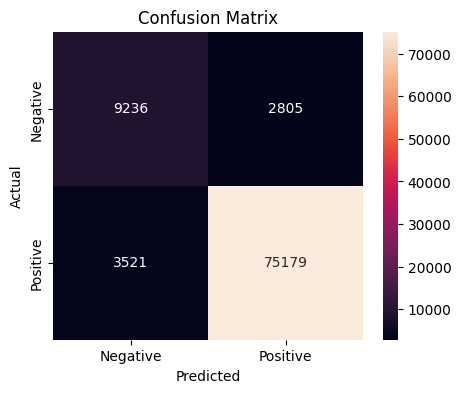

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:

report = classification_report(
    y_true,
    y_pred,
    target_names=["Negative", "Positive"],
    digits=2
)

print(report)

              precision    recall  f1-score   support

    Negative       0.72      0.77      0.74     12041
    Positive       0.96      0.96      0.96     78700

    accuracy                           0.93     90741
   macro avg       0.84      0.86      0.85     90741
weighted avg       0.93      0.93      0.93     90741



In [27]:
model.save_pretrained("./camelbert_final")
tokenizer.save_pretrained("./camelbert_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./camelbert_final/tokenizer_config.json', './camelbert_final/tokenizer.json')